### Imports

In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time


from scipy.stats import binned_statistic
from scipy.interpolate import interp1d
from scipy.sparse.linalg import LinearOperator, splu
from scipy.sparse.linalg._isolve.utils import make_system
from scipy.sparse.linalg import bicgstab, cg
from scipy.sparse import csr_matrix

In [2]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### Functions

#### Solvers

In [3]:
def _get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
    """
    A helper function to handle tolerance normalization
    """
    if atol == 'legacy' or atol is None or atol < 0:
        msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
            "if set, `atol` must be a real, non-negative number.")
        raise ValueError(msg)
    
    print(f'         * rtol: {float(rtol)}')
    
    atol = max(float(atol), float(rtol) * float(b_norm))
    print(f'         * final tolerance: {atol}')
    
    return atol, rtol
    
def cg_(A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):
    A, M, x, b, postprocess = make_system(A, M, x0, b)
    bnrm2 = np.linalg.norm(b)
    
    atol, _ = _get_atol_rtol('cg', bnrm2, atol, rtol)
    
    if bnrm2 == 0:
        return postprocess(b), 0
    
    n = len(b)
    
    if maxiter is None:
        maxiter = int(n*1e4)
    print("maxiter: ", maxiter)
    
    dotprod = np.vdot if np.iscomplexobj(x) else np.dot
    
    matvec = A.matvec
    psolve = M.matvec
    r = b - matvec(x) if x.any() else b.copy()
    
    # Dummy value to initialize var, silences warnings
    rho_prev, p = None, None
    
    p_prev = None
    r_prev = None
    
    for iteration in range(maxiter):
        print("iteration: ", iteration)
        print("          actual tolerance: ", np.linalg.norm(r))
        if np.linalg.norm(r) < atol:  # Are we done?
            print("  --> CGM converged in ", iteration, " iterations")
            return postprocess(x), 0
        
        z = psolve(r)
        rho_cur = dotprod(r, z)
        if iteration > 0:
            beta = rho_cur / rho_prev
            p *= beta
            p += z
    
    
            # Verificación de la conjugación con la dirección anterior
            conjugacy = dotprod(p_prev, matvec(p))
            print(f"Conjugacy check (should be close to 0): {conjugacy}")
            if np.abs(conjugacy) > 1e-10:  # Umbral de tolerancia
                print(f"!!!!!!!! Warning: Loss of conjugacy at iteration {iteration} (value: {conjugacy})")
    
            # Verificación de la ortogonalidad de los residuos
            orthogonality = dotprod(r_prev, r)
            print(f"Orthogonality check (should be close to 0): {orthogonality}")
            if np.abs(orthogonality) > 1e-10:
                print(f"!!!!!!!! Warning: Loss of orthogonality at iteration {iteration} (value: {orthogonality})")
    
        else:  # First spin
            p = np.empty_like(r)
            p[:] = z[:]
    
        q = matvec(p)
        alpha = rho_cur / dotprod(p, q)
        x += alpha*p
        r -= alpha*q
        rho_prev = rho_cur
    
        p_prev = p.copy()
        r_prev = r.copy()
    
        if callback:
            callback(x)
    
    else:  # for loop exhausted
        # Return incomplete progress
        return postprocess(x), maxiter

def bicgstab_(A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):
        print("     * BICGSTAB")
        A, M, x, b, postprocess = make_system(A, M, x0, b)
        bnrm2 = np.linalg.norm(b)

        atol, _ = _get_atol_rtol('bicgstab', bnrm2, atol, rtol)

        if bnrm2 == 0:
            return postprocess(b), 0

        n = len(b)

        dotprod = np.vdot if np.iscomplexobj(x) else np.dot

        if maxiter is None:
            maxiter = n*10
        print("         * maxiter: ", maxiter)

        matvec = A.matvec
        psolve = M.matvec

        # These values make no sense but coming from original Fortran code
        # sqrt might have been meant instead.
        rhotol = np.finfo(x.dtype.char).eps**2
        omegatol = rhotol

        # Dummy values to initialize vars, silence linter warnings
        rho_prev, omega, alpha, p, v = None, None, None, None, None

        r = b - matvec(x) if x.any() else b.copy()
        rtilde = r.copy()

        for iteration in range(maxiter):
            print("             .. iteration: ", iteration)
            tol_ = np.linalg.norm(r) 
            print("       -> actual tol: ", str(tol_), "vs ", str(atol))
            if tol_ < atol:  # Are we done?
                print("        * CGM converged in ", iteration, " iterations")
                return postprocess(x), 0

            rho = dotprod(rtilde, r)
            if np.abs(rho) < rhotol:  # rho breakdown
                return postprocess(x), -10

            if iteration > 0:
                if np.abs(omega) < omegatol:  # omega breakdown
                    return postprocess(x), -11

                beta = (rho / rho_prev) * (alpha / omega)
                p -= omega*v
                p *= beta
                p += r
            else:  # First spin
                s = np.empty_like(r)
                p = r.copy()

            phat = psolve(p)
            v = matvec(phat)
            rv = dotprod(rtilde, v)
            if rv == 0:
                return postprocess(x), -11
            alpha = rho / rv
            r -= alpha*v
            s[:] = r[:]

            if np.linalg.norm(s) < atol:
                x += alpha*phat
                return postprocess(x), 0

            shat = psolve(s)
            t = matvec(shat)
            omega = dotprod(t, s) / dotprod(t, t)
            x += alpha*phat
            x += omega*shat
            r -= omega*t
            rho_prev = rho

            if callback:
                callback(x)

        else:  # for loop exhausted
            # Return incomplete progress
            return postprocess(x), maxiter


#### Profile functions

In [4]:
def get_radial_profile(frank_object,  n_bins, range_):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    r = np.hypot(x, y)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned


def get_radial_profile_deprojected(frank_object, n_bins, range):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = (frank_object._Geometry._pa- 90)*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)


    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [5]:
def get_vis_profile(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn
    pixel_size = (u[1]-u[0])
    q = np.hypot(u, v)
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    if range is None:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    else:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned


def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [6]:
def deproject(u, v, inc, pa, inverse=False):  
    inc *= const.deg_to_rad
    pa *= const.deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    if inverse:
        sin_t *= -1
        u = u / np.cos(inc)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    if inverse:
        return up, vp
    else:
    #   Deproject
        wp = up * np.sin(inc)
        up = up * np.cos(inc)

        return up, vp

def deproject_real_space(frank_object):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    
    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    x_d = (x * cos_pa + y * sin_pa)/cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    return x_d, y_d

#### CGM

In [7]:
def linear_operator(A, size):
    def dot_product(x):
        return A.dot(x)

    return LinearOperator(size, matvec=dot_product)

In [8]:
def P_k(r, k):
    if k == 0:
        return np.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3
    else:
        raise ValueError("k must be 0, 1, or 2.")

In [9]:
def kernel_row(u, v, i, u2 = None, v2 = None):
    def power_spectrum(q, m, c):
        if not np.isscalar(q):  
            q[q == 0] = min_freq
        elif q == 0:
            q = min_freq
        return (q**m)*np.exp(c)
    
    j, k = 4, 1
    H = 2*1.897367*l

    q = np.hypot(u, v)
    power_spectrum_q1 = power_spectrum(q, m, c)
    uh = u/H
    vh = v/H

    q2 = uh2 = vh2 =  None

    if isinstance(u2, np.ndarray):
        q2 = np.hypot(u2[i], v2[i])
        uh2 = u2[i]/H
        vh2 = v2[i]/H
    else:
        q2 = q[i]
        uh2 = uh[i]
        vh2 = vh[i]

    amp = np.sqrt(power_spectrum_q1 * power_spectrum(q2, m, c))
    
    r_normalized = np.sqrt((uh-uh2)**2 + (vh-vh2)**2)
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0

    return amp * factor * P_k(r_normalized, k)

In [10]:
def create_sparse_kernel(kernel_function, u, v, u2 = None, v2 = None):
    data = []
    indices = []
    indptr = [0]
    size1 = size2 = None

    if isinstance(u2, np.ndarray):
        size1 = len(u2)
        size2 = len(u)
    else:
        size1 = size2 = len(u)

    for i in range(size1):
        if isinstance(u2, np.ndarray):  
            row = kernel_function(u, v, i, u2 = u2, v2 = v2)
        else:
            row = kernel_function(u, v, i)
        non_zero_indices = np.nonzero(row)[0]
    
        kernel_values = row[non_zero_indices]
        
        data.extend(kernel_values)
        indices.extend(non_zero_indices)
        indptr.append(len(data))

    data = np.array(data)
    indices = np.array(indices)
    indptr = np.array(indptr)

    size = (size1, size2)

    kernel_csr = csr_matrix((data, indices, indptr), shape=size)

    kernel = linear_operator(kernel_csr, size)

    return kernel

## TODO

*Steps to follow*:
-  separate data from no data
-  construct  matrix $S_{11}$
-  construct V* = $(I + N^{-1} S_{11})^{-1} N^{-1} V_{data}$

### Data

In [11]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "../../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [12]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

#### Let's see the gridded visibilities

In [13]:
N = 300
m , c, l = -0.33, -0.1, 1e5

In [14]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [15]:
frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


Enforcing Hermitian symmetry...
  --> time = 0.01  min |  0.66 seconds
Setting gridded data...


In [16]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [17]:
len(u_gridded)

90000

In [18]:
def write_visibility_data(filename, u, v, Re, Im, Weights):
    with open(filename, 'w') as f:
        f.write("# u[lambda]    v[lambda]    Vis[Jy]    weight\n")
        
        for i in range(0, len(u)):
            f.write(f"{u[i]:.6e}    {v[i]:.6e}  {Re[i]:.6e}   {Im[i]:.6e}   {Weights[i]:.6e}\n")
            
#write_visibility_data(dir + "AS209_continuum_prom_1chan_30s_keepflagsFalse_gridded_N" + str(N)+ ".txt", u_gridded, v_gridded, vis_gridded.real ,vis_gridded.imag,  weights_gridded)

In [19]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):.1f}" if abs(x) > 1e-8 else "0"

#### What is data and what is not data?

In [20]:
#input = np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))
input = weights_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)
input_shifted = np.fft.fftshift(weights_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))

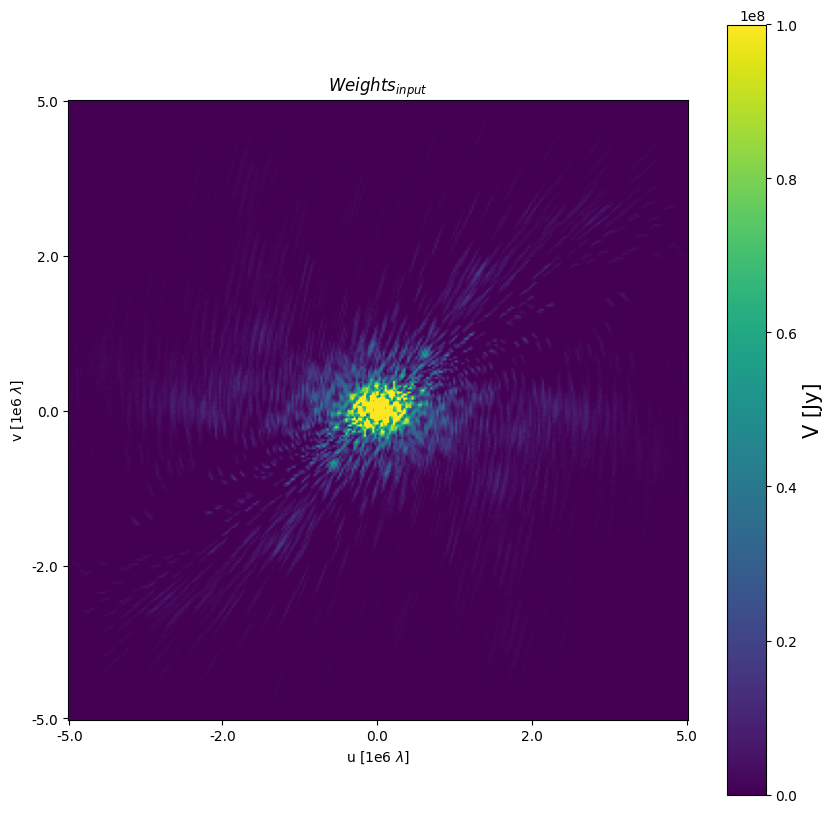

In [21]:
plt.figure(figsize=(10, 10))
plt.imshow(np.fft.fftshift(input.reshape(frank2d._FT._Nx, frank2d._FT._Ny)), origin='lower', vmin=0, vmax=1e8)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'$Weights_{input}$')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [23]:
data_index = np.argwhere(input.flatten() != 0)
no_data_index = np.argwhere(input.flatten() == 0) 

In [24]:
threshold = 2
data_index_m = np.argwhere(np.log(np.abs(input_shifted)) >= threshold)
no_data_index_m = np.argwhere((np.log(np.abs(input_shifted)) < threshold)) 

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_76387/2344609173.py:2: RuntimeWarning: divide by zero encountered in log
  data_index_m = np.argwhere(np.log(np.abs(input_shifted)) >= threshold)
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_76387/2344609173.py:3: RuntimeWarning: divide by zero encountered in log
  no_data_index_m = np.argwhere((np.log(np.abs(input_shifted)) < threshold))


In [25]:
data_index_m2 = np.argwhere(input != 0)
no_data_index_m2 = np.argwhere(input == 0) 

In [26]:
data_index_m2

array([[  0,   0],
       [  0,   1],
       [  0,   2],
       ...,
       [299, 297],
       [299, 298],
       [299, 299]])

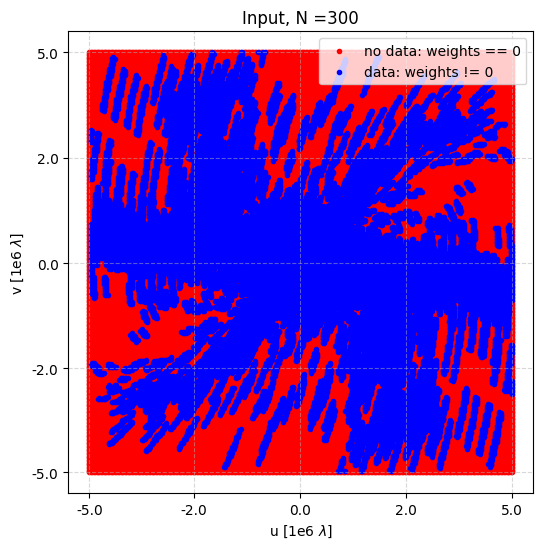

In [27]:
x_no_data, y_no_data = no_data_index_m[:, 1], no_data_index_m[:, 0]
x_data, y_data = data_index_m[:, 1], data_index_m[:, 0]

plt.figure(figsize=(6,6))
#plt.scatter(x_no_data, y_no_data, color='red', marker='.', label='log|no data| < $10^{' + str(threshold)+'}$')
#plt.scatter(x_data, y_data, color='blue', marker='.', label='log|data| > $10^{' + str(threshold)+'}$')
plt.scatter(x_no_data, y_no_data, color='red', marker='.', label='no data: weights == 0')
plt.scatter(x_data, y_data, color='blue', marker='.', label='data: weights != 0')

plt.gca().invert_yaxis()  # Para que el índice 0 esté arriba (como en imshow)
plt.legend(loc = 'upper right')
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.gca().invert_yaxis() 
plt.title(F'Input, N ={N}')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [28]:
len(data_index)

34853

In [29]:
len(data_index)/len(no_data_index)

0.6320017408018569

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_76387/3340702802.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)


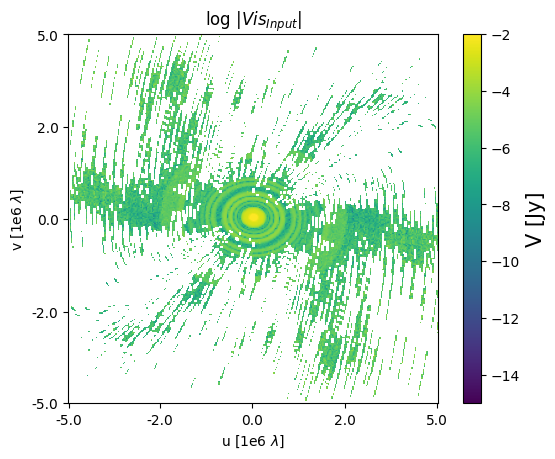

In [30]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [31]:
# data
u_gridded_data = u_gridded[data_index].flatten()
v_gridded_data = v_gridded[data_index].flatten()
vis_gridded_data  = vis_gridded[data_index].flatten()
vis_gridedd_data = np.array(vis_gridded_data, dtype='c16')
weights_gridded_data = weights_gridded[data_index].flatten()

In [32]:
u_gridded_no_data = u_gridded[no_data_index].flatten()
v_gridded_no_data = v_gridded[no_data_index].flatten()
vis_gridded_no_data  = vis_gridded[no_data_index].flatten()
weights_gridded_no_data = weights_gridded[no_data_index].flatten()

 We intend to solve now:  
    $(I + N^{-1} S_{11})$  V* = $N^{-1} V_{data}$

## Solving system with raw matrix multiplication

## Solving system  with Conjugate Gradient Method

#### x0

In [33]:
min_freq = np.sort(np.abs(np.unique(v_gridded_data)))[1]
print("min freq " ,min_freq)

min freq  34377.4677078494


In [34]:
start_time = time.time()

print("------> Creating linear operators")
S11_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data)
S12_T_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, u2 = u_gridded_no_data, v2 = v_gridded_no_data)

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

------> Creating linear operators
  --> time = 4.98  min |  298.82 seconds


In [35]:
N_data = vis_gridded_data.shape[0]

def create_sparse_system_data():
    data_A = []
    indices_A = []
    indptr_A = [0]

    data_Aprecond = []
    indices_Aprecond = []
    indptr_Aprecond = [0]

    data_b = []
    indices_b = []
    indptr_b = [0]

    weights = weights_gridded_data
    
    for i in range(N_data):  
        row = kernel_row(u_gridded_data, v_gridded_data, i)
        non_zero_indices = np.nonzero(row)[0]
        
        non_zero_values = row[non_zero_indices]
        Nm1_S_values = non_zero_values * weights[i]

        # A
        diagonal_pos = np.where((non_zero_indices == i))[0][0]
        Nm1_S_values[diagonal_pos] += 1
        diag_value = Nm1_S_values[diagonal_pos]
        
        data_A.extend(Nm1_S_values)
        indices_A.extend(non_zero_indices)
        indptr_A.append(len(data_A))

        # Preconditioner of A
        data_Aprecond.extend([diag_value**(-1)])
        indices_Aprecond.extend([i])
        indptr_Aprecond.append(len(data_Aprecond))
        
    data_A = np.array(data_A)
    indices_A = np.array(indices_A)
    indptr_A = np.array(indptr_A)

    data_Aprecond = np.array(data_Aprecond)
    indices_Aprecond = np.array(indices_Aprecond)
    indptr_Aprecond = np.array(indptr_Aprecond)

    A_csr = csr_matrix((data_A, indices_A, indptr_A), shape=(N_data, N_data))
    A_precond_csr = csr_matrix((data_Aprecond, indices_Aprecond, indptr_Aprecond), shape=(N_data, N_data))

    A = linear_operator(A_csr, (N_data, N_data))
    A_precond = linear_operator(A_precond_csr, (N_data, N_data))
    b = weights * vis_gridded_data

    return A, A_precond, b

start_time = time.time()
print("------> Creating sparse system")

A_opt, A_precond_opt, b_opt = create_sparse_system_data()

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

------> Creating sparse system
  --> time = 2.00  min |  119.73 seconds


In [36]:
start_time = time.time()
print("------> Running CGM")

x_data, info = bicgstab_(A_opt, b_opt, M = A_precond_opt, rtol = 1e-9)
C_ = x_data

# Report on the success of the fitting
print("  --> CGM converged?  ", info == 0)
fit_correctly = np.allclose(A_opt.matvec(C_), b_opt)
print("  --> Fit correctly?  ", fit_correctly)
if fit_correctly:
    print("                                    !!!!!!!!!!!!!!!!!!!")

end_time = time.time()
execution_time = end_time - start_time
print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')


def recovering_sol(C):
    V_1_m = S11_linearOp.matvec(C)
    V_2_m = S12_T_linearOp.matvec(C)
    
    V_m = np.zeros((N, N), dtype = 'c16')
    
    data_coords = np.unravel_index(data_index.flatten(), (N, N))
    no_data_coords = np.unravel_index(no_data_index.flatten(), (N, N))
    
    V_m[data_coords] = V_1_m
    V_m[no_data_coords] = V_2_m

    u_m = np.zeros((N, N))
    v_m = np.zeros((N, N))
    
    u_m[data_coords] = u_gridded_data
    u_m[no_data_coords] = u_gridded_no_data
    
    v_m[data_coords] = v_gridded_data
    v_m[no_data_coords] = v_gridded_no_data
    
    return V_m

V_m_2 = recovering_sol(C_)

------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance: 0.24674209476190728
         * maxiter:  348530
             .. iteration:  0
       -> actual tol:  246742094.76190728 vs  0.24674209476190728
             .. iteration:  1
       -> actual tol:  52456205.594616175 vs  0.24674209476190728
             .. iteration:  2
       -> actual tol:  36150281.30298042 vs  0.24674209476190728
             .. iteration:  3
       -> actual tol:  26634139.41943198 vs  0.24674209476190728
             .. iteration:  4
       -> actual tol:  18693358.41461992 vs  0.24674209476190728
             .. iteration:  5
       -> actual tol:  12189331.092625264 vs  0.24674209476190728
             .. iteration:  6
       -> actual tol:  9989832.687193485 vs  0.24674209476190728
             .. iteration:  7
       -> actual tol:  8950167.408406902 vs  0.24674209476190728
             .. iteration:  8
       -> actual tol:  9100575.640775917 vs  0.24674209476190728
       

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_76387/2217369007.py:3: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(np.fft.fftshift(V_m_2))), cmap="viridis", vmin=-12, vmax=-2)


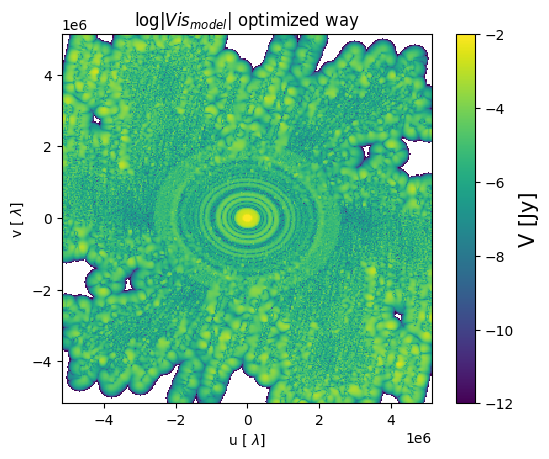

In [37]:
plt.pcolormesh(np.fft.fftshift(v_gridded.reshape(N, N)),
               np.fft.fftshift(u_gridded).reshape(N,N),
               np.log(np.abs(np.fft.fftshift(V_m_2))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$| optimized way')
plt.show()


## Comparison of profiles

In [38]:
geom = Geometry(inc, pa, dra, ddec)

In [39]:
frank2d_2 = Frank2D(N, Rout, geom)
frank2d_2.preprocess_vis(u, v, Vis, Weights, hermitian= True)
frank2d_2.sol_visibility = V_m_2

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


Enforcing Hermitian symmetry...
  --> time = 0.01  min |  0.52 seconds
Setting gridded data...


In [36]:
# frank1d
sol = frank2d_2.frank1d(u, v, Vis, Weights)

### Frank2D

In [37]:
frank2d0 = Frank2D(N, Rout, geom)
frank2d0.set_kernel('Wendland', [m, c, 1e5])
frank2d0.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15, frank1d_guess = False)

Setting kernel: Wendland...
Gridding...
Enforcing Hermitian symmetry...
  --> time = 0.01  min |  0.66 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 7.84  min |  470.26 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 1.757743259956663e-07
         * maxiter:  900000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteratio

In [38]:
vis_sol_f2d = frank2d0.sol_visibility

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_20429/597994223.py:12: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_sol_f2d.reshape(frank2d0._FT._Nx, frank2d0._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


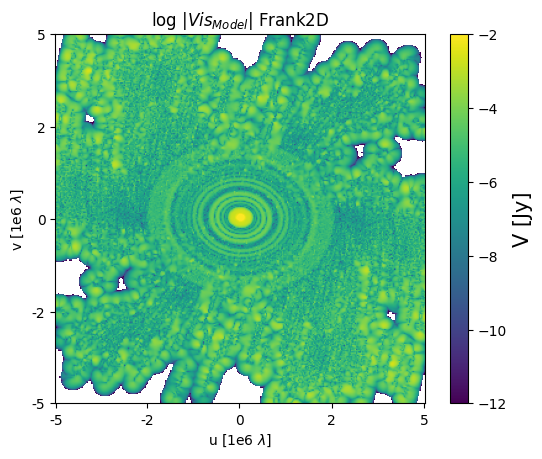

In [44]:
FT = frank2d0._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):d}" if abs(x) > 1e-8 else "0"

plt.imshow(np.log(np.abs(np.fft.fftshift(vis_sol_f2d.reshape(frank2d0._FT._Nx, frank2d0._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Model}$| Frank2D')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

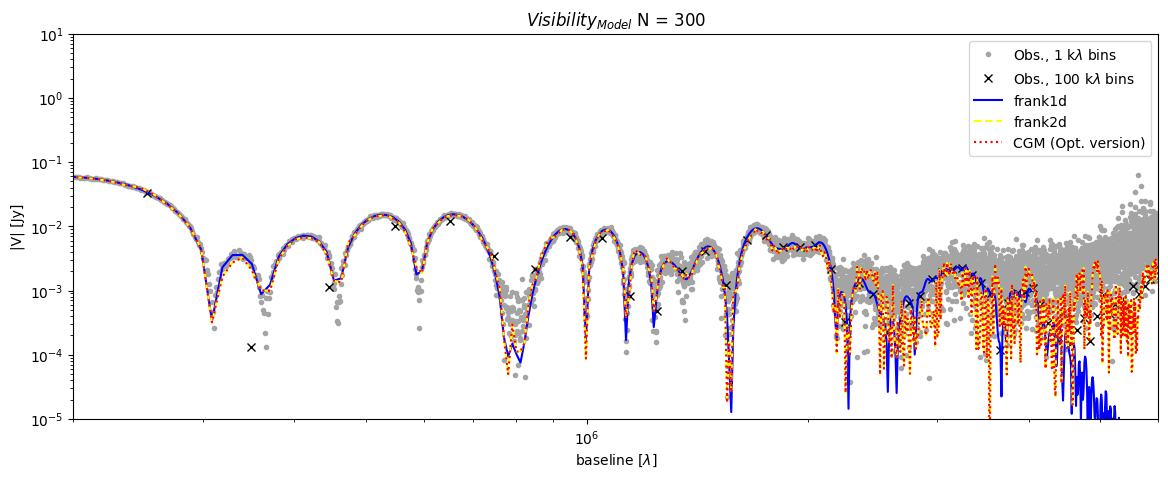

In [40]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -------------------------- BINS----------------------------------------------------------
#frank1d
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
# Vis from pure multiplication
#q, Vis_d1 = get_vis_profile_deprojected(frank2d_1, baselines_edges, range, weighted = False)
#plt.plot(baselines_centers, np.abs(Vis_d1), label = f'Matrix multiplication (Opt. version)',ls=':')

# ---------------------------------------------------------------------------------------------
# Oficial Frank2d
#frank2d deprojected
q, Vis_d3 = get_vis_profile_deprojected(frank2d0, baselines_edges, range, weighted = False)
plt.plot(baselines_centers, np.abs(Vis_d3), label = f'frank2d', color = 'yellow', ls='--')
# ---------------------------------------------------------------------------------------------
# Vis from CGM
q, Vis_d2 = get_vis_profile_deprojected(frank2d_2, baselines_edges, range, weighted = False)
plt.plot(baselines_centers, np.abs(Vis_d2), label = f'CGM (Opt. version)',color ='red', ls=':')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 10)
plt.xlim(2e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Model}$ N = ' + str(N))
plt.legend(fontsize= 10, loc = 'best')
plt.show()